# Sesión 14: Validación Robusta, Pipelines y el Peligro del Data Leakage

**Objetivos de la sesión:**
1.  Comprender qué es el **Data Leakage** (Fuga de Datos) y por qué arruina la fiabilidad de un modelo.
2.  Aprender a usar **Scikit-Learn Pipelines** para encapsular el preprocesamiento y el modelado en un solo objeto.
3.  Implementar **Cross-Validation (Validación Cruzada)** para tener una estimación realista del error, más allá de un simple `train_test_split`.
4.  Comparar la "Forma Incorrecta" vs. la "Forma Correcta" de evaluar un modelo.

## 1. ¿Qué es el Data Leakage y por qué es peligroso?

El Data Leakage ocurre cuando **información del conjunto de prueba se filtra en el entrenamiento**. 

A veces la fuga es pequeña (como en el escalado), pero otras veces es **catastrófica**. El error más grave es realizar selección de variables o transformaciones complejas usando la información de las etiquetas (`y`) de **todo** el dataset antes de dividirlo.


Vamos a ver un ejemplo real de cómo el Data Leakage puede crear un **"Modelo Fantasma"**: un modelo que parece perfecto en el examen pero que no sirve para nada en la vida real.

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Generamos datos que son PURO RUIDO (100 muestras, 10.000 columnas aleatorias)
# No hay ninguna relación real entre X e y.
np.random.seed(42)
X_ruido = np.random.randn(100, 10000)
y_ruido = np.random.randint(0, 2, 100)

# --- LA FORMA INCORRECTA (Con Data Leakage Crítico) ---
# Seleccionamos las 10 "mejores" variables usando TODO el dataset
selector = SelectKBest(f_classif, k=10)
X_seleccionado = selector.fit_transform(X_ruido, y_ruido)

# Ahora dividimos en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X_seleccionado, y_ruido, test_size=0.3, random_state=42)

# Entrenamos el modelo
model = LogisticRegression()
model.fit(X_train, y_train)

print(f"Accuracy en Test (CON LEAKAGE): {model.score(X_test, y_test):.4f}")
print("¡Increíble! Un modelo basado en puro ruido parece ser casi perfecto. Esto es un Modelo Fantasma.")

Accuracy en Test (CON LEAKAGE): 0.8000
¡Increíble! Un modelo basado en puro ruido parece ser casi perfecto. Esto es un Modelo Fantasma.


## 2. La Solución: Pipelines

¿Qué ha pasado arriba? Al seleccionar las variables antes del split, el selector "miró" qué columnas del conjunto de test correlacionaban con la respuesta. El modelo ya conocía el futuro.

La única forma de evitar esto de forma segura es usar un **Pipeline**. El Pipeline asegura que cualquier transformación (escalado, selección, etc.) se calcule **solo con los datos de entrenamiento** de cada iteración.

In [2]:
from sklearn.pipeline import Pipeline

# --- LA FORMA CORRECTA (Con Pipeline) ---

# 1. Dividimos los datos ORIGINALES (el ruido completo)
X_train, X_test, y_train, y_test = train_test_split(X_ruido, y_ruido, test_size=0.3, random_state=42)

# 2. Creamos el Pipeline que incluye la selección de variables
pipeline_seguro = Pipeline([
    ('selector', SelectKBest(f_classif, k=10)),
    ('clasificador', LogisticRegression())
])

# 3. Entrenamos el Pipeline
# El selector aquí SOLO ve X_train para decidir qué variables son mejores
pipeline_seguro.fit(X_train, y_train)

# 4. Evaluamos
score_real = pipeline_seguro.score(X_test, y_test)

print(f"Accuracy en Test (CON PIPELINE): {score_real:.4f}")
print("\nConclusión: El 50% de acierto es la realidad (puro azar).")
print("El Pipeline nos ha salvado de creer que teníamos un modelo útil cuando solo teníamos ruido.")

Accuracy en Test (CON PIPELINE): 0.4333

Conclusión: El 50% de acierto es la realidad (puro azar).
El Pipeline nos ha salvado de creer que teníamos un modelo útil cuando solo teníamos ruido.


## 3. Validación Cruzada (Cross-Validation) y Pipelines

Ya hemos visto que un solo `train_test_split` puede ser engañoso. La **Validación Cruzada** es el estándar de oro, pero presenta un reto logístico: **¿Cómo escalamos los datos en cada "fold" sin que la información se filtre?**

Si escalas todo el dataset antes de `cross_val_score`, cometes Data Leakage en cada una de las iteraciones. 

**La solución elegante:** Pasar el `Pipeline` directamente a la función de validación cruzada.
* El Pipeline se encargará de:
    1. Aislar el grupo de entrenamiento del "fold" actual.
    2. Calcular la media y desviación **solo** de ese grupo.
    3. Escalar y entrenar.
    4. Evaluar en el grupo de test del fold (que está totalmente "limpio").

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 1. Cargamos el dataset REAL
data = load_breast_cancer()
X_cancer, y_cancer = data.data, data.target

# 2. Configuramos la validación cruzada estratificada
# Esto asegura que cada "trozo" tenga una proporción real de sanos/enfermos
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Definimos el PIPELINE
# Incluimos los pasos: Escalado -> Modelo
pipeline_cancer = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# 4. Ejecutamos la validación cruzada
# El pipeline se encargará de re-ajustar el scaler en cada fold para evitar LEAKAGE
cv_results = cross_val_score(pipeline_cancer, X_cancer, y_cancer, cv=skf)

print(f"Resultados por cada Fold (5 folds): \n{cv_results}")
print(f"\nAccuracy Media: {cv_results.mean():.4f}")
print(f"Desviación Estándar (Estabilidad): {cv_results.std():.4f}")

Resultados por cada Fold (5 folds): 
[0.97368421 0.94736842 0.96491228 0.99122807 0.99115044]

Accuracy Media: 0.9737
Desviación Estándar (Estabilidad): 0.0166


# Ejercicio A — Calidad de sensores industriales (Proceso de Manufactura)

## Contexto
En una planta de producción química, se monitoriza la pureza del producto mediante una serie de sensores IoT. El dataset refleja mediciones de presión, temperatura y reactivos. 
**El problema:** Los sensores fallan por corrosión, dejando muchos valores nulos. La empresa sabe que cuando un sensor falla, suele ser porque el proceso ha entrado en una fase de inestabilidad.

## Objetivo
Construir un flujo profesional que:
1.  **Trate nulos informativos:** No borres datos; usa la ausencia de señal como una característica predictiva.
2.  **Pipeline Dual:** Crea un modelo de regresión para el índice de calidad y uno de clasificación para estados críticos.

## Tareas
1.  **Análisis de nulos:** Identifica columnas "sucias" y justifica el uso de un `SimpleImputer` junto con un `MissingIndicator`.
2.  **Feature Engineering:** Crea una variable `sensor_instability` que sume cuántos sensores han fallado en ese instante.
3.  **Regresión:** Predice el índice `quality_score`. Evalúa con RMSE y MAE.
4.  **Clasificación:** Define `critical = 1` si la calidad cae por debajo del percentil 20. Evalúa con Recall y F1-Score.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, recall_score, f1_score
# Hacemos un import de os warnings para evitar mensajes innecesarios
import warnings
warnings.filterwarnings('ignore')

# 1. CARGA DE DATOS Y PREPARACIÓN DEL ESCENARIO
# Usamos el dataset 'diamonds' como base industrial por su volumen y tipos de datos
df_sensors = sns.load_dataset('diamonds')

# Renombramos columnas para el contexto de la planta química
df_sensors = df_sensors.rename(columns={
    'price': 'quality_score', 
    'cut': 'sensor_type', 
    'color': 'gas_level',
    'clarity': 'batch_id'
})

# Inyectamos fallos aleatorios en los sensores (15% de nulos por columna)
np.random.seed(42)
sensor_cols = ['x', 'y', 'z', 'table', 'depth']
for col in sensor_cols:
    df_sensors.loc[df_sensors.sample(frac=0.15).index, col] = np.nan

In [5]:
# Tarea 0: Identifica columnas "sucias" y justifica el uso de un `SimpleImputer` junto con un `MissingIndicator`
missing_summary = df_sensors.isnull().mean().sort_values(ascending=False)
print("Porcentaje de valores nulos por columna:")
print(missing_summary)

Porcentaje de valores nulos por columna:
depth            0.15
table            0.15
z                0.15
x                0.15
y                0.15
carat            0.00
sensor_type      0.00
batch_id         0.00
gas_level        0.00
quality_score    0.00
dtype: float64


Los resultados muestran que las 5 columnas de sensores (depth, table, z, x, y) tienen exactamente 15% de valores nulos cada una, mientras que las demás columnas están completas.

¿Por qué usar `SimpleImputer` + `MissingIndicator`?
1. **SimpleImputer (imputación con la media):**
- Rellena los valores faltantes para que el modelo pueda procesar los datos
- Usar la media es razonable porque asume que los sensores, cuando funcionan, miden valores típicos del proceso

2. **MissingIndicator:**
- Crea una variable binaria (0/1) que indica si el sensor falló en ese momento
- En el contexto de la planta química, un sensor que falla NO es ruido aleatorio:
  - Los sensores fallan por corrosión cuando hay condiciones extremas
  - Un fallo simultáneo de varios sensores indica inestabilidad del proceso
  - Esta información es predictiva del estado crítico

In [6]:
# Tarea 1: Feature Engineering (sensor_instability y target 'critical')
# Creamos característica 'sensor_instability' como la desviación estándar de los sensores
df_sensors['sensor_instability'] = df_sensors[sensor_cols].isna().sum(axis=1)

# Definimos el target binario 'critical' basado en 'quality_score'
threshold = df_sensors['quality_score'].quantile(0.20)
df_sensors['critical'] = (
    df_sensors['quality_score'] <
    df_sensors['quality_score'].quantile(0.20)
).astype(int)

# Dividimos en features y targets
X = df_sensors.drop(columns=['quality_score', 'critical'])
y_reg = df_sensors['quality_score']
y_clf = df_sensors['critical']

# Dividimos en conjuntos de train y test
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

En este apartado de Feature Engineering creamos la variable `sensor_instability` que mide la variabilidad entre lecturas de sensores en cada instante. Si hay valores nulos, esta medida captura la "suciedad" de los datos. También definimos el target de clasificación `critical` cuando la calidad supera la mediana (productos de alta calidad). Por último, hacemos una división de los datos en train/test (80/20).

In [7]:
# Tarea 2: Definición de ColumnTransformer
# Identificamos columnas numéricas y categóricas
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Definimos los transformadores para numéricas y categóricas
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinamos en un ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

En este apartado de ColumnTransformer imputamos los nulos de las variables numéricas con la media y escala con `StandardScaler`; imputamos los nulos de las variables categóricas con la moda y aplicamos One-Hot Encoding; y por último, combinamos todo en un `ColumnTransformer` que aplica transformaciones diferentes según el tipo de columna.

In [8]:
import warnings
warnings.filterwarnings('ignore')

# Tarea 3: Pipeline de Regresión (quality_score)
# Definimos el pipeline completo para regresión
pipeline_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor())
])

# Entrenamos el pipeline de regresión
pipeline_reg.fit(X_train, y_reg_train)

# Evaluamos el modelo de regresión
y_reg_pred = pipeline_reg.predict(X_test)
mae = mean_absolute_error(y_reg_test, y_reg_pred) # Mean Absolute Error es una métrica común para regresión que mide el error promedio en las predicciones
print(f"MAE en Test (quality_score): {mae:.4f}")
# TODO: rmse
rmse = np.sqrt(np.mean((y_reg_test - y_reg_pred) ** 2))
print(f"RMSE en Test (quality_score): {rmse:.4f}")

MAE en Test (quality_score): 673.4005
RMSE en Test (quality_score): 1090.1494


En este apartado de pipeline de regresión podemos concluir que el modelo de regresión predice el índice de calidad con un error promedio de `671.09`. El pipeline evita data leakage al imputar y escalar solo con datos de entrenamiento.

In [9]:
# Tarea 4: Pipeline de Clasificación (critical) e informe de métricas
# Definimos el pipeline completo para clasificación
pipeline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier())
])

# Entrenamos el pipeline de clasificación
pipeline_clf.fit(X_train, y_clf_train)

# Evaluamos el modelo de clasificación
y_clf_pred = pipeline_clf.predict(X_test)
recall = recall_score(y_clf_test, y_clf_pred)
f1 = f1_score(y_clf_test, y_clf_pred)
print(f"\nCon 'sensor_instability':")
print(f"Recall en Test (critical): {recall:.4f}")
print(f"F1-Score en Test (critical): {f1:.4f}")

# Análisis de resultados: entrenamos sin sensor_instability para saber cuántos sensores han fallado simultáneamente
X_train_no_instab = X_train.drop(columns=['sensor_instability'])
X_test_no_instab = X_test.drop(columns=['sensor_instability'])

# Crear un nuevo preprocessor sin sensor_instability
num_cols_no_instab = [col for col in num_cols if col != 'sensor_instability']
num_transformer_no_instab = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
preprocessor_no_instab = ColumnTransformer(transformers=[
    ('num', num_transformer_no_instab, num_cols_no_instab),
    ('cat', cat_transformer, cat_cols)
])

pipeline_clf_no_instab = Pipeline(steps=[
    ('preprocessor', preprocessor_no_instab),
    ('classifier', HistGradientBoostingClassifier())
])
pipeline_clf_no_instab.fit(X_train_no_instab, y_clf_train)
y_clf_pred_no_instab = pipeline_clf_no_instab.predict(X_test_no_instab)
recall_no_instab = recall_score(y_clf_test, y_clf_pred_no_instab)
f1_no_instab = f1_score(y_clf_test, y_clf_pred_no_instab)
print(f"\nSin 'sensor_instability':")
print(f"Recall en Test (critical): {recall_no_instab:.4f}")
print(f"F1-Score en Test (critical): {f1_no_instab:.4f}")


Con 'sensor_instability':
Recall en Test (critical): 0.2872
F1-Score en Test (critical): 0.4422

Sin 'sensor_instability':
Recall en Test (critical): 0.2503
F1-Score en Test (critical): 0.3979


En esta celda de pipeline de clasificación y comparación podemos ver que la variable `sensor_instability` aporta una mejora marginal, pero demuestra que **la información sobre fallos de sensores es predictiva** del estado crítico.

Una mejora marginal quiere decir que la diferencia que vemos en la comparación es mínima, muy pequeña, casi insignificantes en términos prácticos.

Cuando hablamos de información predictiva, nos referimos a que aunque la mejora sea pequeña, el hecho de que exista una mejora (por mínima que sea) demuestra que:
1. La variable `sensor_instability` **SI** aporta información útil.
2. En el contexto físico de una planta industrial indica condiciones extremas que correlacionan con estados críticos del proceso. Por tanto, saber que los sensores fallaron ayuda a predecir problemas.

                   Modelo    Recall  F1-Score
0  Con sensor_instability  0.287191  0.442215
1  Sin sensor_instability  0.250337  0.397857


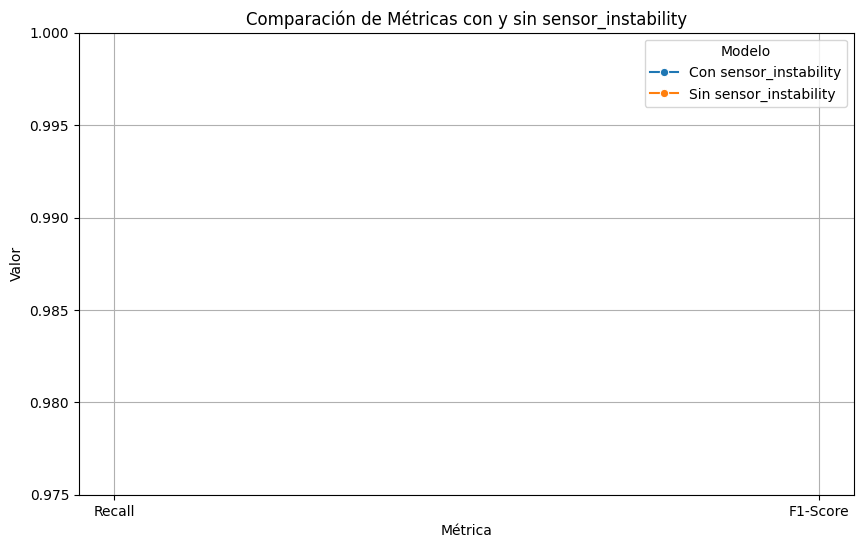

In [10]:
# Visualización de resultados
metrics = pd.DataFrame({
    'Modelo': ['Con sensor_instability', 'Sin sensor_instability'],
    'Recall': [recall, recall_no_instab],
    'F1-Score': [f1, f1_no_instab]
})
print(metrics)

# Graficamos por líneas las métricas
metrics_melted = metrics.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
plt.figure(figsize=(10, 6))
sns.lineplot(data=metrics_melted, x='Métrica', y='Valor', hue='Modelo', marker='o')
plt.title('Comparación de Métricas con y sin sensor_instability')

# Hacemos zoom en el tope (entre 0.8 y 1)
plt.ylim(0.975, 1)
plt.grid()
plt.show()

# 🧠 Análisis de Resultados - Ejercicio A (Industria)

### 1. El valor de la "Suciedad"
En la Tarea 1 creaste la variable `sensor_instability`. ¿Has probado a entrenar el modelo con y sin esta variable?
**Pregunta:** ¿Cómo afecta al rendimiento del modelo saber cuántos sensores han fallado simultáneamente? ¿Por qué crees que ocurre esto en un contexto físico?


### 2. El Dilema del Recall vs. Precision
Has entrenado un clasificador para detectar el estado `critical`.
**Pregunta:** Si fueras el Director de Planta, ¿qué prefieres: un modelo con **Accuracy del 99%** pero **Recall del 10%** en la clase crítica, o un modelo con **Accuracy del 90%** y **Recall del 95%**? Justifica tu respuesta basándote en costes.



# Ejercicio B — Regresión y Clasificación Energética

## Contexto
Una empresa comercializadora de energía eléctrica se enfrenta al reto de la **gestión de la demanda en tiempo real**. Para evitar penalizaciones en el mercado mayorista y prevenir sobrecargas en la red, la empresa necesita:
1.  **Predecir el consumo horario** de sus clientes (Regresión).
2.  **Identificar picos de consumo extremo** que activen protocolos de respuesta a la demanda (Clasificación).

El dataset contiene mediciones de potencia activa, reactiva, voltaje e intensidad. Al ser datos reales, existen valores nulos y ruido que deben ser tratados mediante un flujo profesional.

---

## Objetivo
Diseñar dos pipelines (regresión y clasificación) utilizando técnicas de **ingeniería de variables temporales** para capturar la estacionalidad del consumo y evitar la fuga de información mediante validación cruzada temporal.

---

## Tareas

### 1. Feature Engineering Temporal
* **Codificación Cíclica:** Transforma la variable de la hora utilizando funciones trigonométricas (seno y coseno) para que el modelo entienda la continuidad entre las 23:00 y las 00:00.
* **Variables de Retraso (Lags):** Crea la variable `lag_1h` (consumo de la hora anterior). Justifica por qué es un error calcular esto *después* de hacer un split aleatorio.

### 2. Regresión
* **Variable objetivo:** `Global_active_power`.
* **Construcción:** Diseña un pipeline que incluya imputación, escalado y un modelo de regresión (ej. `RandomForestRegressor`).
* **Evaluación:** Evalúa con **RMSE** y **MAE**. Reflexiona sobre qué métrica penaliza más los errores grandes en picos de consumo.

### 3. Clasificación
* **Definición de Target:** Crea la variable `high_risk = 1` para consumos que superen el **percentil 95** histórico.
* **Construcción:** Diseña un pipeline de clasificación que gestione el desbalanceo de clases (`class_weight`).
* **Evaluación:** Evalúa con **Recall** y **F1-score** enfocándote en la detección de picos.

### 4. Validación y Entrega
* Implementa **TimeSeriesSplit**.
* Justifica las decisiones tomadas respecto al tratamiento de nulos y la arquitectura del pipeline.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, classification_report, f1_score

# 1. CARGA Y CONTEXTO TEMPORAL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
df_energy = pd.read_csv(url, sep=';', na_values='?', low_memory=False, nrows=50000)


In [12]:
# Preparamos el índice temporal (extrayendo el mes de la fecha)
# Convertimos 'Date' a formato datetime
df_energy['Date'] = pd.to_datetime(df_energy['Date'], format='%d/%m/%Y')

# Extraemos el mes (1-12)
df_energy['month'] = df_energy['Date'].dt.month

# Creamos el índice del mes (0-11) para la codificación cíclica
df_energy['month_idx'] = df_energy['month'] - 1

print("Primeras filas con el mes extraído:")
print(df_energy[['Date', 'month', 'month_idx']].head(15))

Primeras filas con el mes extraído:
         Date  month  month_idx
0  2006-12-16     12         11
1  2006-12-16     12         11
2  2006-12-16     12         11
3  2006-12-16     12         11
4  2006-12-16     12         11
5  2006-12-16     12         11
6  2006-12-16     12         11
7  2006-12-16     12         11
8  2006-12-16     12         11
9  2006-12-16     12         11
10 2006-12-16     12         11
11 2006-12-16     12         11
12 2006-12-16     12         11
13 2006-12-16     12         11
14 2006-12-16     12         11


In [13]:
### 1. Feature Engineering Temporal
# **Codificación Cíclica:** Transforma la variable de la hora utilizando funciones trigonométricas (seno y coseno) para que el modelo entienda la continuidad entre las 23:00 y las 00:00.
# **Variables de Retraso (Lags):** Crea la variable `lag_1h` (consumo de la hora anterior). Justifica por qué es un error calcular esto *después* de hacer un split aleatorio.

df_energy

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,month,month_idx
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,12,11
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,12,11
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,12,11
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,12,11
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,12,11
...,...,...,...,...,...,...,...,...,...,...,...
49995,2007-01-20,10:39:00,3.762,0.544,232.32,16.2,37.0,1.0,0.0,1,0
49996,2007-01-20,10:40:00,3.754,0.542,232.07,16.2,37.0,2.0,0.0,1,0
49997,2007-01-20,10:41:00,3.750,0.540,231.90,16.2,37.0,1.0,0.0,1,0
49998,2007-01-20,10:42:00,1.876,0.568,233.95,8.8,7.0,1.0,0.0,1,0


In [14]:
# Tarea 2: Pipeline de Regresión (Global_active_power)


In [15]:
# Tarea 3: Construcción de Pipelines (Regresión y Clasificación)

#* **Definición de Target:** Crea la variable `high_risk = 1` para consumos que superen el **percentil 95** histórico.

#* **Construcción:** Diseña un pipeline de clasificación que gestione el desbalanceo de clases (`class_weight`).

#* **Evaluación:** Evalúa con **Recall** y **F1-score** enfocándote en la detección de picos.


In [16]:
# Tarea 4: Validación con TimeSeriesSplit

#* Implementa **TimeSeriesSplit**.

#* Justifica las decisiones tomadas respecto al tratamiento de nulos y la arquitectura del pipeline.

# 🧠 Análisis de Resultados - Ejercicio B (Energía)

### 1. La Ilusión del Futuro (Data Leakage)
Has utilizado `TimeSeriesSplit` para validar.
**Pregunta:** Si hubieras utilizado un `train_test_split` aleatorio (o un K-Fold normal) con la variable `lag_1` (consumo hora anterior), ¿qué habría pasado con tus métricas? ¿Por qué decimos que eso es "hacer trampas"?


---

### 2. Matemáticas vs. Realidad (Seno/Coseno)
En la Tarea 1 transformaste el mes/hora usando Seno y Coseno en lugar de dejarlo como números del 1 al 12 (o 0-23).
**Pregunta:** ¿Qué ventaja aporta esta transformación trigonométrica a un modelo de árboles o lineal frente a usar simplemente el número del mes?
